In [1]:
import time
import numpy as np
from matplotlib import pyplot as plt
from examples.seismic.utils import wiener_deconvolution, taper_wavelet, estimate_centroid_frequency_gather
from examples.seismic import SeismicModel, AcquisitionGeometry
from examples.seismic.vti import VTIWaveSolver
from examples.seismic.plotting import plot_two_wavelets, overlay_wiggle_plot
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from devito import info
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as animation
PATH_DATA = path = "../datasets/80_61_PreReady.sgy"
PATH_MODEL = "61_80_var1.dat"
SO = 4
N_GATHER = 100



# region Model definition
spacing = (0.075, 0.075)
velmodel = VelocityModel(PATH_MODEL, dx=spacing[0], dz=spacing[1])

origin = velmodel.x[0], velmodel.z[0]

vp = velmodel.vp.T * 1.03
epsilon = velmodel.epsilon.T
epsilon = velmodel.epsilon.T
delta = velmodel.epsilon.T

# velmodel.plot(show=True)

nbl = 500

model = SeismicModel(
vp=vp,
origin=origin,
shape=vp.shape,
spacing=spacing,
space_order=SO,
epsilon=epsilon,
delta=delta,
nbl=nbl,
bcs="damp",
vti=True,
fs=True,
)

vnx, vnz = model.grid.shape
vnx -= 2*nbl
vnz -= nbl

filename = f"snaps/snaps 101.bin"
nsnaps = 100    

fobj = open(filename, "rb")
snapsObj = np.fromfile(fobj, dtype=np.float32)
snapsObj = np.reshape(snapsObj, (nsnaps, vnx, vnz))
fobj.close()


# qa = np.quantile(snapsObj, 0.98)
# fig, ax = plt.subplots(figsize=(8, 6))
# matrice = ax.imshow(snapsObj[0, :, :].T, vmin=-qa, vmax=qa, cmap="seismic")
# plt.colorbar(matrice)

# plt.xlabel('x')
# plt.ylabel('z')
# plt.tight_layout()
# def update(i):
#     matrice.set_array(snapsObj[i, :, :].T)
#     return matrice,

# # Animation
# ani = animation.FuncAnimation(fig, update, frames=nsnaps, interval=50, blit=True)

# plt.close(ani._fig)
# HTML(ani.to_html5_video())


IndexError: index 4 is out of bounds for axis 1 with size 4

In [121]:
import numpy as np
from scipy.fft import rfftn, irfftn, fftfreq, rfftfreq, ifftn, fftn, fftshift, ifftshift
from typing import Callable
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter



class FKFilter:
    def __init__(self, shape, kz_function: Callable,
                 min_slope=0.1, max_slope=200.,
                 lower_min=0.05, upper_min=0.05,
                 ):
        self.shape = shape
        self.func = kz_function
        self.freq_t = rfftfreq(self.shape[2])
        self.freq_x = fftshift(fftfreq(self.shape[1], d=0.075))
        self.freq_z = fftshift(fftfreq(self.shape[0], d=0.075))
        self.fzz, self.fxx, self.ftt = np.meshgrid(self.freq_z, self.freq_x, self.freq_t, indexing='ij')
        self.min_slope = min_slope
        self.max_slope = max_slope
        self.lower_min = lower_min
        self.upper_min = upper_min
        self.f_shape = (self.freq_z.size, self.freq_x.size, self.freq_t.size)
        self.filter_3d = self._sigmoid_3d(min_slope, max_slope, lower_min, upper_min)
        self.spec = None
        # self._design_fk_filter()

    def apply_filter(self, signal, store_filtered=True):
        spectrum = self.forward(signal)
        # spectrum = self.filter_3d*np.abs(spectrum) * np.exp(1j*np.angle(spectrum))
        spectrum = self.filter_3d*spectrum
        if store_filtered:
            self.spec = spectrum
        return self.inverse(spectrum)

    def forward(self, signal):
        return fftshift(rfftn(signal), axes=(0, 1))
    
    def inverse(self, spectrum):
        return irfftn(ifftshift(spectrum, axes=(0, 1)))

    def store_spec(self, signal):
        self.spec = self.forward(signal)

    def _sigmoid_3d(self, min_slope, max_slope, lower_min, upper_min, eps=0.01, sigma=(1, 1, 1), gaussian_sigma=0.5):
        # abs_fxx = np.abs(self.fxx)
        abs_fxx = np.copy(self.fxx)

        lower_bound = min_slope * abs_fxx + lower_min
        upper_bound = max_slope * abs_fxx + upper_min
        mask = (self.fzz > lower_bound) & (self.fzz < upper_bound) & (self.fxx >0 )
        mask |=  (self.fzz < lower_bound) & (self.fzz > upper_bound) & (self.fxx < 0)
        # mask = self.fzz < upper_bound
        buff = np.where(mask, 1, 0)
        buff = buff * (1 - eps) + eps
        buff = gaussian_filter(buff.astype(float), sigma=sigma)

        r_sq = (self.fxx)**2 + (self.fzz)**2  # Squared distance from center
        gaussian_attenuation = 1 - np.exp(-r_sq / (2 * gaussian_sigma**2))  # 1 at edges, 0 at center
        buff = self.func(buff)
        buff *= gaussian_attenuation  # Reduce central magnitudes
        return buff

    def get_kz_over_kx_limits(self):
    # Get flattened arrays of frequencies (ignore kt since we're working in x-z plane)
        kx = np.abs(self.fxx.flatten())  # Wavenumber in x-direction
        kz = np.abs(self.fzz.flatten())  # Wavenumber in z-direction
        
        # Mask to exclude kx = 0 (avoid division by zero)
        mask = (kx != 0)
        kx_nonzero = kx[mask]
        kz_nonzero = kz[mask]

        mask = (kz_nonzero != 0)
        kx_nonzero = kx_nonzero[mask]
        kz_nonzero = kz_nonzero[mask]
        
        # Compute kz/kx ratios
        kz_over_kx = kz_nonzero / kx_nonzero
        
        # Get min and max (excluding infinities if any)
        valid_ratios = kz_over_kx[np.isfinite(kz_over_kx)]
        kz_kx_min = np.quantile(valid_ratios, 0.05)
        kz_kx_max = np.quantile(valid_ratios, 0.95)
        
        return kz_kx_min, kz_kx_max
    
    def plot_filter_slice(self, t_idx=0, lims=None):
        plt.figure(figsize=(10, 6))
        plt.imshow(self.filter_3d[:, :, t_idx], 
                extent=[self.freq_x.min(), self.freq_x.max(),
                        self.freq_z.min(), self.freq_z.max()],
                origin='lower', cmap='viridis', vmin=0, vmax=1)
        if lims:
            plt.xlim([-lims[0], lims[0]])
            plt.ylim([-lims[1], lims[1]])
        plt.xlabel("fx")
        plt.ylabel("fz")
        plt.colorbar(label="Filter amplitude")
        plt.title("FK Filter Slice (fx-fz plane)")
        plt.show()

    def plot_spec_slice(self, t_idx=0, lims=None):
        plt.figure(figsize=(10, 6))

        plt.imshow(np.log(np.abs(self.spec[:, :, t_idx] ** 2)), 
                extent=[self.freq_x.min(), self.freq_x.max(),
                        self.freq_z.min(), self.freq_z.max()],
                origin='lower', cmap='viridis')
        if lims:
            plt.xlim([-lims[0], lims[0]])
            plt.ylim([-lims[1], lims[1]])
        plt.xlabel("fx")
        plt.ylabel("fz")
        plt.colorbar(label="Filter amplitude")
        plt.title("FK Filter Slice (fx-fz plane)")
        plt.show()

In [122]:
# Usage:
fk_filter = FKFilter(snapsObj.T.shape, kz_function=lambda x:1-x)
fk_filter.store_spec(snapsObj.T)

/tmp/ipykernel_4738/2083640593.py:107: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(self.spec[:, :, t_idx] ** 2)),


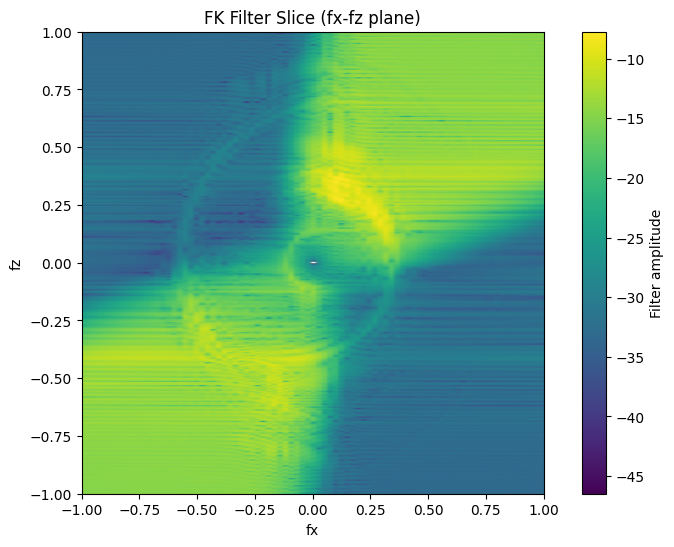

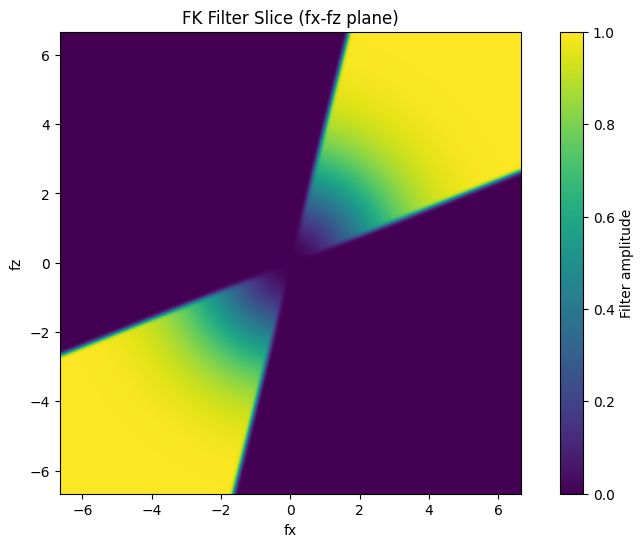

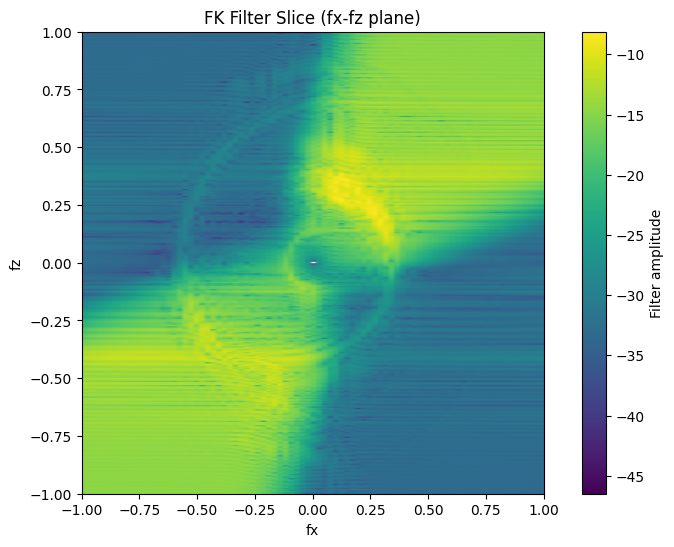

In [158]:
fk_filter.func = lambda x: x
slope = 0.4
fk_filter.filter_3d = fk_filter._sigmoid_3d(slope, 4, 0.0, 0.0, sigma=(10, 2.5, 1), eps=1e-4, gaussian_sigma=2)
fk_filter.plot_spec_slice(t_idx=25, lims=[1, 1])
fk_filter.plot_filter_slice(t_idx=25)
sd = fk_filter.apply_filter(snapsObj.T)
fk_filter.plot_spec_slice(t_idx=25, lims=[1, 1])

In [159]:
sd = np.transpose(sd)
sd = np.real(sd)

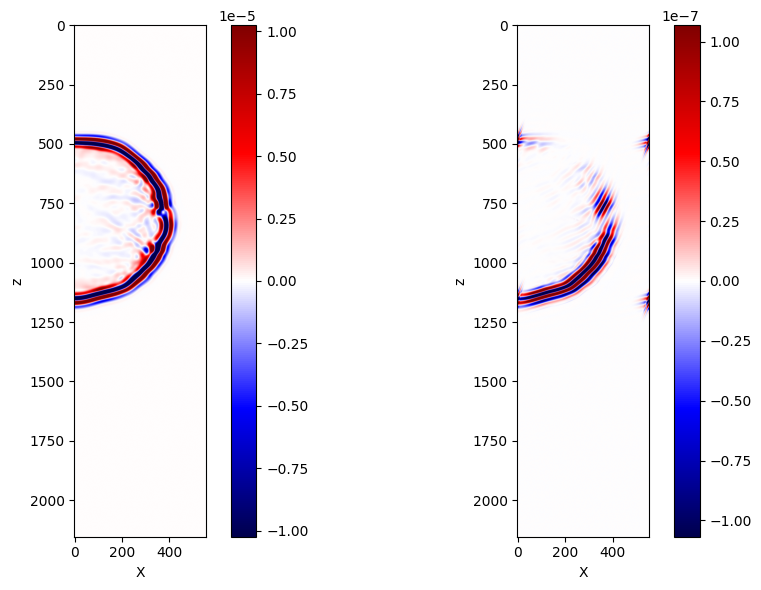

In [160]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
qa = np.quantile(snapsObj, 0.996)
matrice0 = ax[0].imshow(snapsObj[15, :, :].T, vmin=-qa, vmax=qa, cmap="seismic")
qa = np.quantile(sd, 0.998)
matrice2 = ax[1].imshow(sd[15, :, :].T, vmin=-qa, vmax=qa, cmap="seismic")
fig.colorbar(matrice0)
fig.colorbar(matrice2)

for axi in ax:
    axi.set_xlabel('X')
    axi.set_ylabel('z')

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 6))
qa1 = np.quantile(snapsObj, 0.999)
qa2 = np.quantile(sd, 0.999)

matrice1 = ax[0].imshow(snapsObj[0, :, :].T, vmin=-qa1, vmax=qa1, cmap="seismic")
matrice2 = ax[1].imshow(sd[0, :, :].T, vmin=-qa2, vmax=qa2, cmap="seismic")
fig.colorbar(matrice1)
fig.colorbar(matrice2)

for axi in ax:
    axi.set_xlabel('X')
    axi.set_ylabel('z')

plt.tight_layout()
def update(i):
    matrice1.set_array(snapsObj[i, :, :].T)
    matrice2.set_array(sd[i, :, :].T)
    
    return matrice1, matrice2, 

# Animation
ani = animation.FuncAnimation(fig, update, frames=nsnaps, interval=50, blit=True)

plt.close(ani._fig)
HTML(ani.to_html5_video())